In [7]:
import os
import sys

sys.path.append(
    os.path.abspath("..")
)

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBRegressor
from xgboost import XGBClassifier

import shap

sns.set_style("whitegrid")

In [10]:
df = pd.read_csv(
    "../data/insurance_cleaned.csv",
    low_memory=False
)

In [11]:
df["VehicleAge"] = (
    2015 - df["RegistrationYear"]
)

In [12]:
df["ClaimOccurred"] = (
    df["TotalClaims"] > 0
).astype(int)

In [13]:
df["Margin"] = (
    df["TotalPremium"] -
    df["TotalClaims"]
)

In [14]:
severity_df = df[
    df["TotalClaims"] > 0
].copy()

In [19]:
features = [
    "Province",
    "VehicleType",
    "make",
    "CoverType",
    "RegistrationYear",
    "CustomValueEstimate",
    "kilowatts",
    "Cylinders",
    "SumInsured",
    "CalculatedPremiumPerTerm",
    "VehicleAge"
]

In [16]:
target = "TotalClaims"

In [22]:
X = severity_df[features]

y = severity_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
df.columns.tolist()

['UnderwrittenCoverID',
 'PolicyID',
 'TransactionMonth',
 'IsVATRegistered',
 'Citizenship',
 'LegalType',
 'Title',
 'Language',
 'Bank',
 'AccountType',
 'MaritalStatus',
 'Gender',
 'Country',
 'Province',
 'PostalCode',
 'MainCrestaZone',
 'SubCrestaZone',
 'ItemType',
 'mmcode',
 'VehicleType',
 'RegistrationYear',
 'make',
 'Model',
 'Cylinders',
 'cubiccapacity',
 'kilowatts',
 'bodytype',
 'NumberOfDoors',
 'VehicleIntroDate',
 'CustomValueEstimate',
 'AlarmImmobiliser',
 'TrackingDevice',
 'CapitalOutstanding',
 'NewVehicle',
 'WrittenOff',
 'Rebuilt',
 'Converted',
 'CrossBorder',
 'NumberOfVehiclesInFleet',
 'SumInsured',
 'TermFrequency',
 'CalculatedPremiumPerTerm',
 'ExcessSelected',
 'CoverCategory',
 'CoverType',
 'CoverGroup',
 'Section',
 'Product',
 'StatutoryClass',
 'StatutoryRiskType',
 'TotalPremium',
 'TotalClaims',
 'VehicleAge',
 'ClaimOccurred',
 'Margin']

In [23]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns

numerical_cols = X.select_dtypes(
    exclude=["object"]
).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['Province', 'VehicleType', 'CoverType'], dtype='object')

Numerical Columns:
Index(['RegistrationYear', 'CustomValueEstimate', 'Cylinders', 'SumInsured',
       'CalculatedPremiumPerTerm', 'VehicleAge'],
      dtype='object')


In [24]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_cols
        ),
        (
            "cat",
            categorical_transformer,
            categorical_cols
        )
    ]
)

In [25]:
lr_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

In [26]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

In [27]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBRegressor(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=6,
                random_state=42
            )
        )
    ]
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

In [28]:
def evaluate_regression(
    y_true,
    y_pred
):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return {
        "RMSE": rmse,
        "R2": r2
    }

In [29]:
lr_results = evaluate_regression(
    y_test,
    lr_preds
)

rf_results = evaluate_regression(
    y_test,
    rf_preds
)

xgb_results = evaluate_regression(
    y_test,
    xgb_preds
)

print("Linear Regression:", lr_results)
print("Random Forest:", rf_results)
print("XGBoost:", xgb_results)

Linear Regression: {'RMSE': np.float64(33564.69706328319), 'R2': 0.2994930529918629}
Random Forest: {'RMSE': np.float64(36159.975478763015), 'R2': 0.18697624035513627}
XGBoost: {'RMSE': np.float64(35676.338084345334), 'R2': 0.20857908254703472}


In [30]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE": [
        lr_results["RMSE"],
        rf_results["RMSE"],
        xgb_results["RMSE"]
    ],

    "R2": [
        lr_results["R2"],
        rf_results["R2"],
        xgb_results["R2"]
    ]
})

comparison

,Model,RMSE,R2
0,Linear Regression,33564.697063,0.299493
1,Random Forest,36159.975479,0.186976
2,XGBoost,35676.338084,0.208579


In [31]:
y_class = df["ClaimOccurred"]

X_class = df[features]

In [32]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

In [33]:
rf_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

rf_classifier.fit(
    X_train_c,
    y_train_c
)

class_preds = rf_classifier.predict(
    X_test_c
)

In [34]:
classification_results = {
    "Accuracy": accuracy_score(
        y_test_c,
        class_preds
    ),

    "Precision": precision_score(
        y_test_c,
        class_preds
    ),

    "Recall": recall_score(
        y_test_c,
        class_preds
    ),

    "F1": f1_score(
        y_test_c,
        class_preds
    )
}

classification_results

{'Accuracy': 0.997090290970903, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}

In [35]:
X_processed = preprocessor.fit_transform(X_train)

In [36]:
xgb_shap_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_shap_model.fit(
    X_processed,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [37]:
explainer = shap.Explainer(
    xgb_shap_model
)

shap_values = explainer(
    X_processed
)

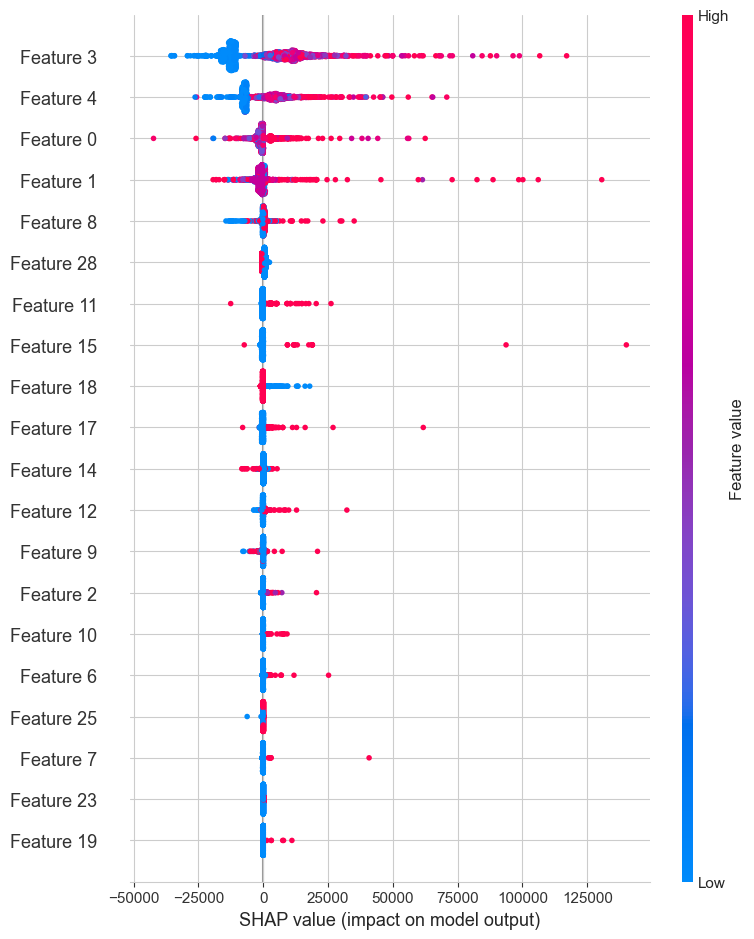

In [38]:
shap.summary_plot(
    shap_values,
    X_processed
)

In [39]:
from src.modeling import (
    evaluate_regression,
    evaluate_classification
)